# ** Appendix B. Choice of the number of clusters for the EC regime ** 

Note that since the squared error $J(K)$ always decreases as we increase $K$, solving this
problem requires fixing the number of clusters $K$. In our particular case we take advantage
of the symmetric nature of the POD subspace to guide the choice of $K$. Because of the
discrete flow symmetries $\lbrace \mathbb{S}_x , \mathbb{S}_y , \mathrm{R}_\pi \rbrace$ the computed clusters are bound to be organised in groups $G_k$: groups of 4 clusters, where none of the elements of the group satisfy a particular symmetry, groups of 2 clusters, where each element of the group is invariant by the action of one of the symmetries, and groups of a single cluster. An adequate number of clusters K results from a good compromise between a small number of clusters and the decrease in the squared error $J(K)$. Moreover, the computed clusters are required to verify the above symmetry rules.

In this routine, we compare the partition of the EC subset using different numbers of 
clusters. 

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the time series

In [2]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'

In [3]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
POD_pr3 = pd.read_hdf(filename_modes_pr3)

POD_pr3['f']=POD_pr3['k1'].abs()
scale_pr3 = POD_pr3.mean()['f']

pod_pr3 = POD_pr3[['k1','k2','k3','k4','k5','k6','f']]/POD_pr3.mean()['f']
pod_pr3['t'] = glb_pr3.t
pod_pr3['CRregime'] = glb_pr3.CRregime

thres_pr3=glb_pr3.mean()['f'] + glb_pr3.std()['f']

del POD_pr3

In [4]:
glb_pr43 = pd.read_hdf(filename_global_pr43)
POD_pr43 = pd.read_hdf(filename_modes_pr43)

POD_pr43['f']=POD_pr43['k1'].abs()
scale_pr43 = POD_pr43.mean()['f']
pod_pr43 = POD_pr43[['k1','k2','k3','k4','k5','k6','f']]/POD_pr43.mean()['f']
pod_pr43['t'] = glb_pr43.t
pod_pr43['k4'] = -pod_pr43.k4
pod_pr43['CRregime'] = glb_pr43.CRregime

thres_pr43=glb_pr43.mean()['f'] + glb_pr43.std()['f']


del POD_pr43

## 2. Apply the symmetry operators

In [5]:
cr = pod_pr3.loc[pod_pr3.CRregime==False]
k1 = np.concatenate(( cr.k1.values,-cr.k1.values,-cr.k1.values, cr.k1.values))
k3 = np.concatenate(( cr.k3.values,-cr.k3.values,-cr.k3.values, cr.k3.values))
k2 = np.concatenate(( cr.k2.values, cr.k2.values, cr.k2.values, cr.k2.values))
k5 = np.concatenate(( cr.k5.values, cr.k5.values, cr.k5.values, cr.k5.values))
k4 = np.concatenate(( cr.k4.values,-cr.k4.values, cr.k4.values,-cr.k4.values))
k6 = np.concatenate(( cr.k6.values, cr.k6.values,-cr.k6.values,-cr.k6.values))

alpha_cr_pr3 = np.array([k1,k2,k3,k4,k5,k6])

## 3. Partition the subspace using different values of $K$

In [6]:
def get_clusters(n_clusters, X):

    import pickle
    from sklearn.cluster import KMeans

    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=20, n_jobs=-2).fit(X.T)
    cluster = kmeans.predict(X.T)

    print(" Done! ")
    return kmeans, cluster

In [7]:
def cluster_metrics(n_clusters, cluster, kmeans):   

    cluster_no = range(0,n_clusters)
    probability = pd.DataFrame(columns=['Prob'],index=cluster_no)
    transition  = pd.DataFrame(columns=cluster_no, index=cluster_no)

    for i in cluster_no:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    
    for i in cluster_no:
        for j in cluster_no:                
            events = np.where(np.logical_and(cluster[0:-1]==i, cluster[1:]==j))
            transition.loc[j,i] =  np.size(events)
        transition.loc[i,i] = -999999
    
    i=np.argmax(probability['Prob'].values)    
    sorted = [i] 
    for j in range(0,n_clusters-1):    
        next_i=np.nanargmax(transition.loc[i,:].values)
        transition.loc[:,i] = -9999999
        sorted.append(next_i)        
        i = next_i
    
    probability = pd.DataFrame(columns=['Prob'],index=sorted)
    distance    = pd.DataFrame(columns=sorted, index=sorted)
    transition  = pd.DataFrame(columns=sorted, index=sorted)
    
    for i in sorted:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    for i in sorted:
        for j in sorted:        
        
            distance.loc[j,i] = np.sqrt(np.dot(
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:],
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:]))
        
            events = np.where(np.logical_and(cluster[0:-1]==j, cluster[1:]==i))
            transition.loc[j,i] =  np.size(events)
    
    distance = distance.fillna(0)
            
    transition = transition.astype(float).div(transition.sum(axis=0), axis=1)
    transition = transition.fillna(0)
    
    probability = probability.reset_index()
    probability = probability.drop(['index'],axis=1)

    transition = transition.reset_index()
    transition = transition.drop(['index'],axis=1)
    transition.columns=range(0,n_clusters)
    
    distance = distance.reset_index()
    distance = distance.drop(['index'],axis=1)
    distance.columns=range(0,n_clusters)
    
    print(" Done! ")
    return probability, transition, distance, sorted

In [8]:
import pickle
from sklearn.cluster import KMeans


for n_clusters in range(1, 17):
    filename_pr3 = './results_from_kmeans/appendix_k'+'{}'.format(n_clusters)+'_pr3_ec.sav'
    kmeans, cluster = get_clusters(n_clusters, alpha_cr_pr3)
    pickle.dump(kmeans, open(filename_pr3, 'wb'))    
    print(" Done for ", n_clusters, " clusters! ")

 Done! 
 Done for  1  clusters! 
 Done! 
 Done for  2  clusters! 
 Done! 
 Done for  3  clusters! 
 Done! 
 Done for  4  clusters! 
 Done! 
 Done for  5  clusters! 
 Done! 
 Done for  6  clusters! 
 Done! 
 Done for  7  clusters! 
 Done! 
 Done for  8  clusters! 
 Done! 
 Done for  9  clusters! 
 Done! 
 Done for  10  clusters! 
 Done! 
 Done for  11  clusters! 
 Done! 
 Done for  12  clusters! 
 Done! 
 Done for  13  clusters! 
 Done! 
 Done for  14  clusters! 
 Done! 
 Done for  15  clusters! 
 Done! 
 Done for  16  clusters! 


## 4. We compare the different partitions on the (L,Q), (L,S), and (S,S*) planes.

 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 


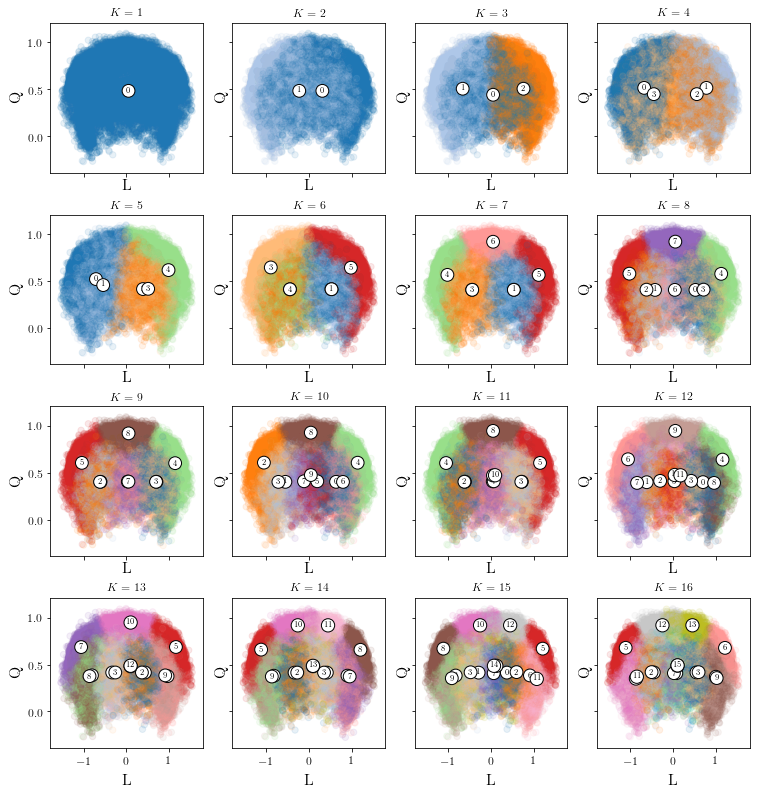

In [9]:
plt.rcParams['figure.figsize'] = (10.5, 11.0)

norm = mpl.colors.Normalize(vmin=0.,vmax=16)

f, axes = plt.subplots(4,4, sharex=True, sharey=True)
ax= np.ravel(axes)

n_samples=25000
shape = np.shape(alpha_cr_pr3)
index = np.random.choice(range(shape[1]),n_samples)
for n_clusters in range(1,17): 
    filename_pr3 = './results_from_kmeans/appendix_k'+'{}'.format(n_clusters)+'_pr3_ec.sav'
    kmeans = pickle.load(open(filename_pr3, 'rb'))
    cluster = kmeans.predict(alpha_cr_pr3[:,index].T)
    probs , trans , dist , sorted = cluster_metrics(n_clusters, cluster,  kmeans)

    sorted_cluster = np.zeros_like(cluster)
    for j in range(0, np.size(cluster)):
        sorted_cluster[j] = np.where(cluster[j]==sorted)[0]

    ax[n_clusters-1].scatter(alpha_cr_pr3[0,index], alpha_cr_pr3[1,index], s=40, alpha=0.1, c=sorted_cluster, rasterized=True, cmap="tab20", norm=norm)
    bbox_props = dict(boxstyle="circle,pad=0.3", fc="w", ec="k", lw=1)
    for i in range(0,n_clusters):
        ax[n_clusters-1].annotate(i, xy=(kmeans.cluster_centers_[sorted[i],0], kmeans.cluster_centers_[sorted[i],1]), xycoords='data', size=8, bbox=bbox_props)

    ax[n_clusters-1].set_xlabel('L')
    ax[n_clusters-1].set_ylabel('Q')
    ax[n_clusters-1].set_title('$K='+'{}'.format(n_clusters)+'$')
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_b1.pdf',dpi=300)

 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 


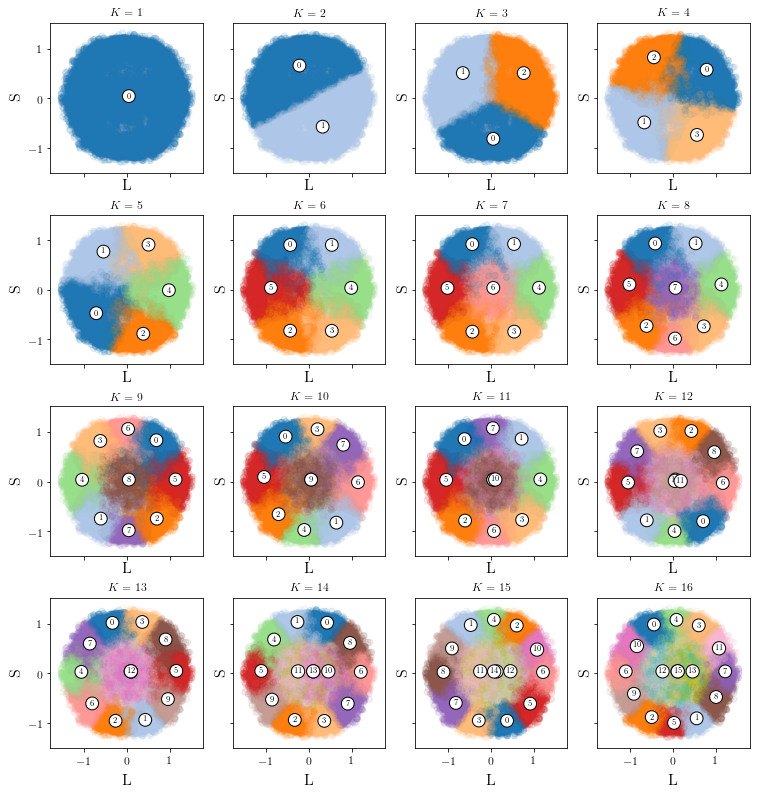

In [12]:
plt.rcParams['figure.figsize'] = (10.5, 11.0)

norm = mpl.colors.Normalize(vmin=0.,vmax=16)

f, axes = plt.subplots(4,4, sharex=True, sharey=True)
ax= np.ravel(axes)

n_samples=25000
shape = np.shape(alpha_cr_pr3)
index = np.random.choice(range(shape[1]),n_samples)
for n_clusters in range(1,17): 
    filename_pr3 = './results_from_kmeans/appendix_k'+'{}'.format(n_clusters)+'_pr3_ec.sav'
    kmeans = pickle.load(open(filename_pr3, 'rb'))
    cluster = kmeans.predict(alpha_cr_pr3[:,index].T)
    probs , trans , dist , sorted = cluster_metrics(n_clusters, cluster,  kmeans)

    sorted_cluster = np.zeros_like(cluster)
    for j in range(0, np.size(cluster)):
        sorted_cluster[j] = np.where(cluster[j]==sorted)[0]

    ax[n_clusters-1].scatter(alpha_cr_pr3[0,index], alpha_cr_pr3[3,index], s=40, alpha=0.1, c=sorted_cluster, rasterized=True, cmap="tab20", norm=norm)
    bbox_props = dict(boxstyle="circle,pad=0.3", fc="w", ec="k", lw=1)
    for i in range(0,n_clusters):
        ax[n_clusters-1].annotate(i, xy=(kmeans.cluster_centers_[sorted[i],0], kmeans.cluster_centers_[sorted[i],3]), xycoords='data', size=8, bbox=bbox_props)

    ax[n_clusters-1].set_xlabel('L')
    ax[n_clusters-1].set_ylabel('S')
    ax[n_clusters-1].set_title('$K='+'{}'.format(n_clusters)+'$')
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_b2.pdf',dpi=300)

 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 
 Done! 


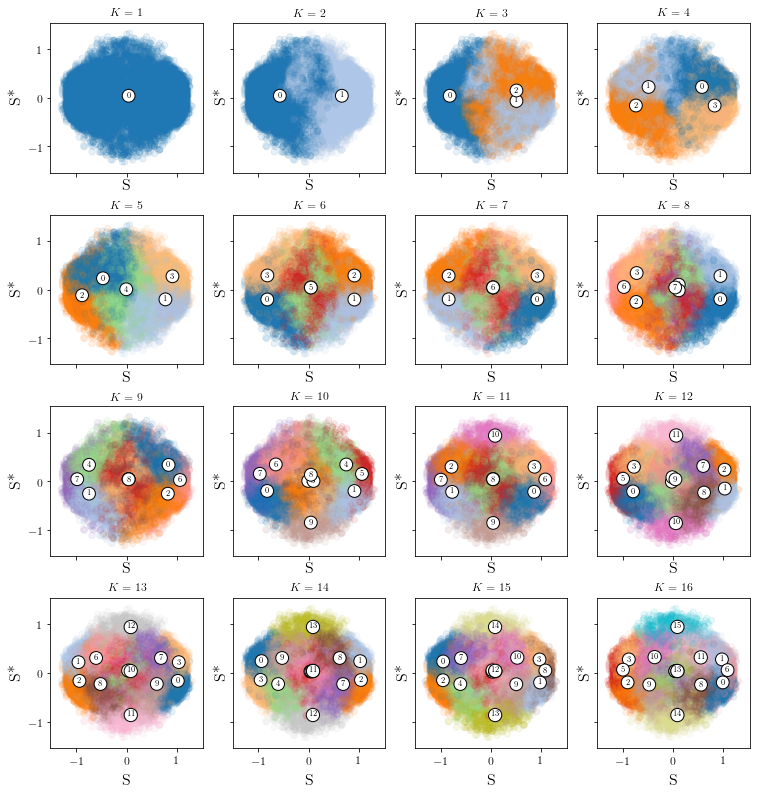

In [11]:
plt.rcParams['figure.figsize'] = (10.5, 11.0)

norm = mpl.colors.Normalize(vmin=0.,vmax=16)

f, axes = plt.subplots(4,4, sharex=True, sharey=True)
ax= np.ravel(axes)

n_samples=25000
shape = np.shape(alpha_cr_pr3)
index = np.random.choice(range(shape[1]),n_samples)
for n_clusters in range(1,17): 
    filename_pr3 = './results_from_kmeans/appendix_k'+'{}'.format(n_clusters)+'_pr3_ec.sav'
    kmeans = pickle.load(open(filename_pr3, 'rb'))
    cluster = kmeans.predict(alpha_cr_pr3[:,index].T)
    probs , trans , dist , sorted = cluster_metrics(n_clusters, cluster,  kmeans)

    sorted_cluster = np.zeros_like(cluster)
    for j in range(0, np.size(cluster)):
        sorted_cluster[j] = np.where(cluster[j]==sorted)[0]

    ax[n_clusters-1].scatter(alpha_cr_pr3[3,index], alpha_cr_pr3[5,index], s=40, alpha=0.1, c=sorted_cluster, rasterized=True, cmap="tab20", norm=norm)
    bbox_props = dict(boxstyle="circle,pad=0.3", fc="w", ec="k", lw=1)
    for i in range(0,n_clusters):
        ax[n_clusters-1].annotate(i, xy=(kmeans.cluster_centers_[sorted[i],3], kmeans.cluster_centers_[sorted[i],5]), xycoords='data', size=8, bbox=bbox_props)

    ax[n_clusters-1].set_xlabel('S')
    ax[n_clusters-1].set_ylabel('S*')
    ax[n_clusters-1].set_title('$K='+'{}'.format(n_clusters)+'$')
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_b3.pdf',dpi=300)